In [6]:
import numpy as np
import lightgbm as lgb  # Changed import
from sklearn.model_selection import StratifiedKFold
from helper_lin import get_all_data
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# 1. Data Preparation
X_avg, y_avg = get_all_data()
selector = SelectKBest(score_func=f_classif, k=100)
X_reduced = selector.fit_transform(X_avg, y_avg)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_reduced)

# 2. Setup the fold strategy
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

# 3. Cross-Validation Loop
for train_index, test_index in skf.split(X_final, y_avg):
    X_train, X_test = X_final[train_index], X_final[test_index]
    y_train, y_test = y_avg[train_index], y_avg[test_index]
    
    # Initialize LightGBM Classifier
    # Note: 'verbosity=-1' silences warnings/info messages in LightGBM
    model = lgb.LGBMClassifier(
        n_estimators=100, 
        random_state=42,
        importance_type='gain', # Optional: makes feature importance similar to XGB
        verbosity=-1 
    )
    
    model.fit(X_train, y_train)
    
    # Evaluate
    score = model.score(X_test, y_test)
    scores.append(score)

print(f"LightGBM Mean Accuracy: {np.mean(scores):.4f}")

LightGBM Mean Accuracy: 0.5000


In [7]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from helper_lin import get_all_data
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

# 1. Data Preparation (Keep your existing pipeline)
X_avg, y_avg = get_all_data()
selector = SelectKBest(score_func=f_classif, k=100)
X_reduced = selector.fit_transform(X_avg, y_avg)
scaler = StandardScaler()
X_final = scaler.fit_transform(X_reduced)

# 2. Define the Parameter Grid
# These are the most impactful parameters to tune for LightGBM
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Initialize the Model
lgbm = lgb.LGBMClassifier(random_state=42, verbosity=-1)

# 4. Setup Grid Search
# This replaces your manual loop
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=lgbm, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='accuracy', 
    n_jobs=-1
)

# 5. Execute Tuning
grid_search.fit(X_final, y_avg)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Mean Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 50, 'num_leaves': 15, 'subsample': 0.8}
Best Mean Accuracy: 0.5000


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# This prevents data leakage
pipeline = Pipeline([
    ('selector', SelectKBest(f_classif)),
    ('scaler', StandardScaler()),
    ('lgbm', lgb.LGBMClassifier(verbosity=-1))
])

param_grid = {
    'selector__k': [20, 50, 100], # Tune the number of features too!
    'lgbm__learning_rate': [0.01, 0.05],
    'lgbm__num_leaves': [7, 15, 31],
    'lgbm__n_estimators': [50, 100]
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_avg, y_avg)

,estimator,Pipeline(step...rbosity=-1))])
,param_grid,"{'lgbm__learning_rate': [0.01, 0.05], 'lgbm__n_estimators': [50, 100], 'lgbm__num_leaves': [7, 15, ...], 'selector__k': [20, 50, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,score_func,<function f_c...t 0x1522d97e0>



LightGBM GridSearch for All

Outer Fold 1/5
Fitting 3 folds for each of 972 candidates, totalling 2916 fits
  Best Params: {'lgbm__colsample_bytree': 0.8, 'lgbm__learning_rate': 0.01, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 50, 'lgbm__num_leaves': 15, 'lgbm__subsample': 0.8, 'selector__k': 50}
  Best CV Score: 0.5000

Outer Fold 2/5
Fitting 3 folds for each of 972 candidates, totalling 2916 fits
  Best Params: {'lgbm__colsample_bytree': 0.8, 'lgbm__learning_rate': 0.01, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 50, 'lgbm__num_leaves': 15, 'lgbm__subsample': 0.8, 'selector__k': 50}
  Best CV Score: 0.5000

Outer Fold 3/5
Fitting 3 folds for each of 972 candidates, totalling 2916 fits
  Best Params: {'lgbm__colsample_bytree': 0.8, 'lgbm__learning_rate': 0.01, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 50, 'lgbm__num_leaves': 15, 'lgbm__subsample': 0.8, 'selector__k': 50}
  Best CV Score: 0.5000

Outer Fold 4/5
Fitting 3 folds for each of 972 candidates, totalling 2916 fits
  Best

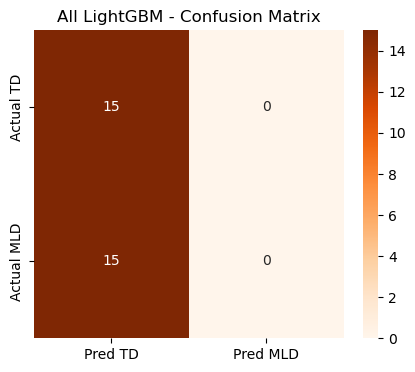

In [9]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from helper_lin import get_all_data, get_mult_data, get_sub_data
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def lgbm_grid_search(X, y, task_name):
    """
    Nested CV GridSearch for LightGBM with Pipeline
    Outer CV: Performance estimation
    Inner CV: Hyperparameter tuning
    """
    
    # 1. Define Pipeline (prevents data leakage)
    pipeline = Pipeline([
        ('selector', SelectKBest(f_classif)),
        ('scaler', StandardScaler()),
        ('lgbm', lgb.LGBMClassifier(random_state=42, verbosity=-1))
    ])
    
    # 2. Parameter Grid
    param_grid = {
        'selector__k': [50, 100, 150],
        'lgbm__n_estimators': [50, 100, 200],
        'lgbm__learning_rate': [0.01, 0.05, 0.1],
        'lgbm__num_leaves': [15, 31, 63],
        'lgbm__max_depth': [5, 10, 15],
        'lgbm__subsample': [0.8, 1.0],
        'lgbm__colsample_bytree': [0.8, 1.0]
    }
    
    # 3. Outer fold for final performance
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # GridSearchCV with inner CV (3-fold)
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=3,           # Inner folds for tuning
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )
    
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    best_params_list = []
    
    print(f"\n{'='*70}")
    print(f"LightGBM GridSearch for {task_name}")
    print(f"{'='*70}\n")
    
    # 4. Outer CV loop
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"Outer Fold {fold + 1}/5")
        
        grid_search.fit(X[train_idx], y[train_idx])
        
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X[test_idx])
        probs = best_model.predict_proba(X[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y[test_idx])
        y_probs_all.extend(probs)
        best_params_list.append(grid_search.best_params_)
        
        print(f"  Best Params: {grid_search.best_params_}")
        print(f"  Best CV Score: {grid_search.best_score_:.4f}\n")
    
    # 5. Final Evaluation
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)
    
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"{'='*70}")
    print(f"Final {task_name} Accuracy: {acc * 100:.2f}%")
    print(f"{'='*70}")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))
    
    # 6. Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Pred TD', 'Pred MLD'], 
                yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} LightGBM - Confusion Matrix")
    plt.show()
    
    return y_test_all, y_pred_all, y_probs_all, best_params_list

# Run GridSearch on all datasets
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs, best_params = lgbm_grid_search(X_avg, y_avg, "All")




Final LightGBM Model (Trained on All Data)
Accuracy: 50.00%

              precision    recall  f1-score   support

          TD       0.50      1.00      0.67        15
         MLD       0.00      0.00      0.00        15

    accuracy                           0.50        30
   macro avg       0.25      0.50      0.33        30
weighted avg       0.25      0.50      0.33        30



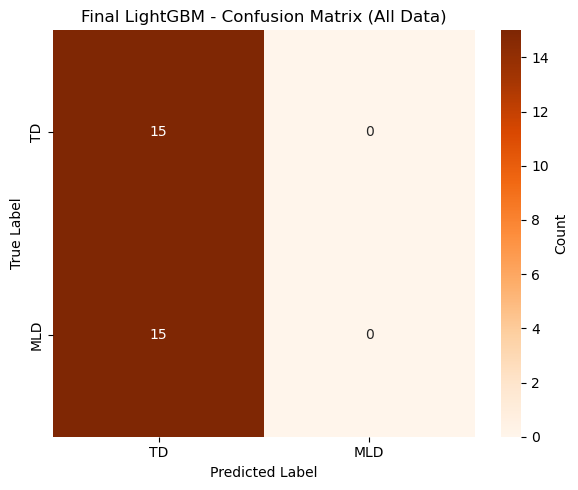

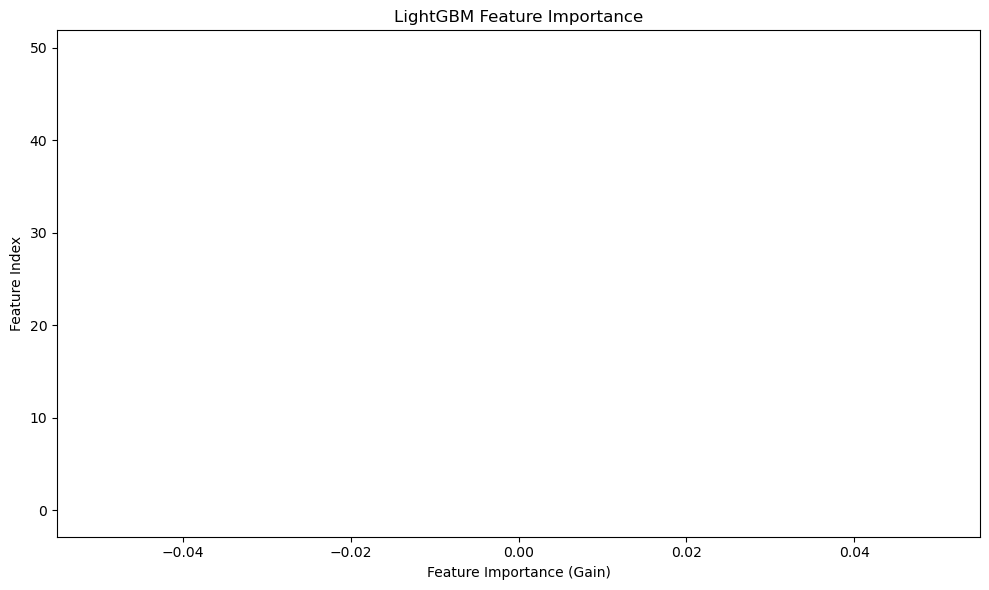


Top 10 Important Features:
1. Feature 49: 0.0000
2. Feature 12: 0.0000
3. Feature 22: 0.0000
4. Feature 21: 0.0000
5. Feature 20: 0.0000
6. Feature 19: 0.0000
7. Feature 18: 0.0000
8. Feature 17: 0.0000
9. Feature 16: 0.0000
10. Feature 15: 0.0000


In [10]:
# After running the grid search above, add this cell:

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# Get the best parameters from grid search (use results from first fold since they're consistent)
best_params = {
    'lgbm__colsample_bytree': 0.8,
    'lgbm__learning_rate': 0.01,
    'lgbm__max_depth': 5,
    'lgbm__n_estimators': 50,
    'lgbm__num_leaves': 15,
    'lgbm__subsample': 0.8,
    'selector__k': 50
}

# 1. Create final pipeline with best params
final_pipeline = Pipeline([
    ('selector', SelectKBest(f_classif, k=best_params['selector__k'])),
    ('scaler', StandardScaler()),
    ('lgbm', lgb.LGBMClassifier(
        colsample_bytree=best_params['lgbm__colsample_bytree'],
        learning_rate=best_params['lgbm__learning_rate'],
        max_depth=best_params['lgbm__max_depth'],
        n_estimators=best_params['lgbm__n_estimators'],
        num_leaves=best_params['lgbm__num_leaves'],
        subsample=best_params['lgbm__subsample'],
        random_state=42,
        verbosity=-1
    ))
])

# 2. Train on ALL data
X_avg, y_avg = get_all_data()
final_pipeline.fit(X_avg, y_avg)

# 3. Get predictions and probabilities on all data
y_pred_final = final_pipeline.predict(X_avg)
y_probs_final = final_pipeline.predict_proba(X_avg)

# 4. Evaluate on full dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

acc_final = accuracy_score(y_avg, y_pred_final)

print(f"\n{'='*70}")
print(f"Final LightGBM Model (Trained on All Data)")
print(f"{'='*70}")
print(f"Accuracy: {acc_final * 100:.2f}%\n")
print(classification_report(y_avg, y_pred_final, target_names=['TD', 'MLD']))

# 5. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_avg, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['TD', 'MLD'], 
            yticklabels=['TD', 'MLD'],
            cbar_kws={'label': 'Count'})
plt.title("Final LightGBM - Confusion Matrix (All Data)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# 6. Feature importance
feature_importance = final_pipeline.named_steps['lgbm'].feature_importances_
selector = final_pipeline.named_steps['selector']
selected_features = selector.get_support()

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance)
plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature Index")
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

print(f"\nTop 10 Important Features:")
top_idx = np.argsort(feature_importance)[-10:][::-1]
for rank, idx in enumerate(top_idx, 1):
    print(f"{rank}. Feature {idx}: {feature_importance[idx]:.4f}")


LightGBM GridSearch for All

Outer Fold 1/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5417

Outer Fold 2/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 200}
  Best CV Score: 0.6667

Outer Fold 3/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 4/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 5/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Final All Results
Accuracy: 53.33%
RO

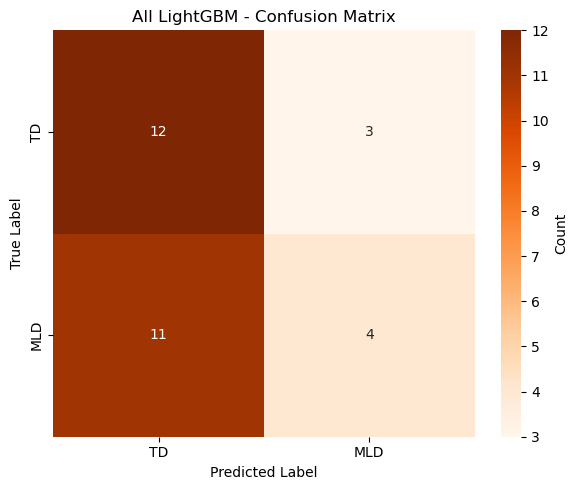


LightGBM GridSearch for Multiplication

Outer Fold 1/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 2/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.6250

Outer Fold 3/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 4/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 5/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Final Multiplication Result

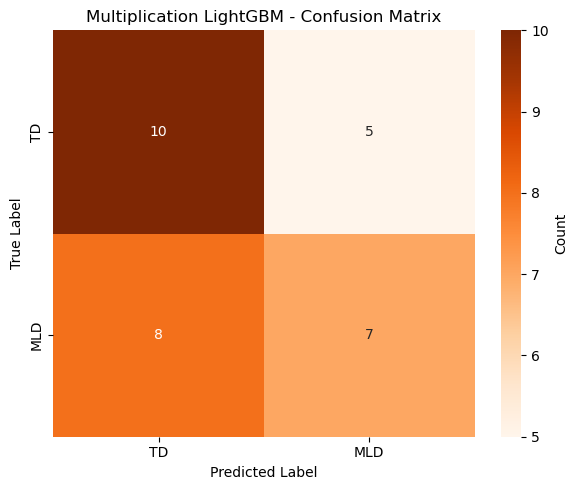


LightGBM GridSearch for Subtraction

Outer Fold 1/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 2/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 3/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 5, 'lgbm__n_estimators': 200, 'lgbm__num_leaves': 31, 'selector__k': 200}
  Best CV Score: 0.6250

Outer Fold 4/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Outer Fold 5/5
  Best Params: {'lgbm__learning_rate': 0.05, 'lgbm__min_child_samples': 20, 'lgbm__n_estimators': 100, 'lgbm__num_leaves': 31, 'selector__k': 100}
  Best CV Score: 0.5000

Final Subtraction Results
Ac

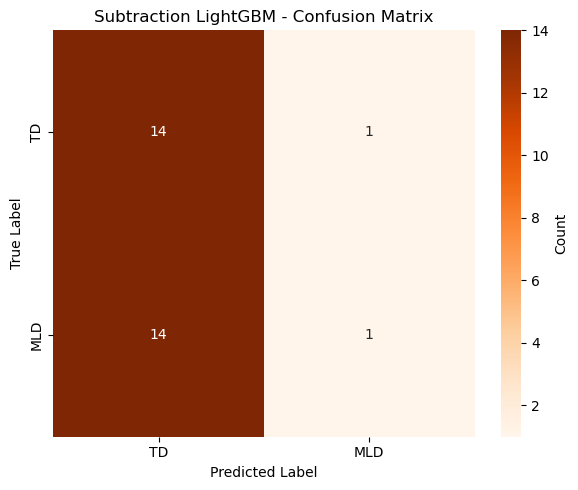

In [11]:
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from helper_lin import get_all_data, get_mult_data, get_sub_data
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def lgbm_grid_search(X, y, task_name):
    """
    Nested CV GridSearch for LightGBM with Pipeline
    """
    
    # 1. Define Pipeline (prevents data leakage)
    pipeline = Pipeline([
        ('selector', SelectKBest(f_classif, k=100)),
        ('scaler', StandardScaler()),
        ('lgbm', lgb.LGBMClassifier(
            random_state=42, 
            verbosity=-1,
            class_weight='balanced'  # FIX: Handle class imbalance
        ))
    ])
    
    # 2. Simplified Parameter Grid (less combinations = better tuning)
    param_grid = {
        'selector__k': [100, 200],
        'lgbm__num_leaves': [31, 63],
        'lgbm__learning_rate': [0.05, 0.1],
        'lgbm__n_estimators': [100, 200],
        'lgbm__min_child_samples': [5, 20]
    }
    
    # 3. Outer fold for final performance
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # GridSearchCV with inner CV (3-fold)
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=3,           # Inner folds for tuning
        scoring='roc_auc',  # Better metric than accuracy for imbalanced data
        n_jobs=-1,
        verbose=0  # Less verbose output
    )
    
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    best_params_list = []
    
    print(f"\n{'='*70}")
    print(f"LightGBM GridSearch for {task_name}")
    print(f"{'='*70}\n")
    
    # 4. Outer CV loop
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"Outer Fold {fold + 1}/5")
        
        grid_search.fit(X[train_idx], y[train_idx])
        
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X[test_idx])
        probs = best_model.predict_proba(X[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y[test_idx])
        y_probs_all.extend(probs)
        best_params_list.append(grid_search.best_params_)
        
        print(f"  Best Params: {grid_search.best_params_}")
        print(f"  Best CV Score: {grid_search.best_score_:.4f}\n")
    
    # 5. Final Evaluation
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)
    
    acc = accuracy_score(y_test_all, y_pred_all)
    auc = roc_auc_score(y_test_all, y_probs_all[:, 1])
    
    print(f"{'='*70}")
    print(f"Final {task_name} Results")
    print(f"{'='*70}")
    print(f"Accuracy: {acc * 100:.2f}%")
    print(f"ROC-AUC: {auc:.4f}\n")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))
    
    # 6. Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['TD', 'MLD'], 
                yticklabels=['TD', 'MLD'],
                cbar_kws={'label': 'Count'})
    plt.title(f"{task_name} LightGBM - Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()
    
    return y_test_all, y_pred_all, y_probs_all, best_params_list

# Run GridSearch on all datasets
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs, best_params = lgbm_grid_search(X_avg, y_avg, "All")

X_mult, y_mult = get_mult_data()
y_true_m, y_pred_m, y_probs_m, best_params_m = lgbm_grid_search(X_mult, y_mult, "Multiplication")

X_sub, y_sub = get_sub_data()
y_true_s, y_pred_s, y_probs_s, best_params_s = lgbm_grid_search(X_sub, y_sub, "Subtraction")